# AdaBoost from Scratch 🚀

In this notebook, we implement **AdaBoost (Adaptive Boosting)**, a powerful ensemble technique.

## 📖 Theoretical Background

AdaBoost combines multiple "weak learners" (usually decision trees with depth 1, called "stumps") to create a strong classifier.

### 1. Sample Weights
Initially, all $n$ samples have equal weight: $w_i = \frac{1}{n}$.

### 2. Training Weak Learners
For each iteration $t$:
1. Train a weak learner to minimize the weighted error $\epsilon_t$.
2. Calculate the "Amount of Say" ($\alpha_t$) for this learner:
   $$\alpha_t = \frac{1}{2} \log\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$
3. Update sample weights so that misclassified samples get higher weight:
   $$w_i \leftarrow w_i \exp(-\alpha_t y_i h_t(x_i))$$
4. Normalize the weights so they sum to 1.

### 3. Final Prediction
The final prediction is the sign of the weighted sum of predictions:
$$\hat{y} = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(X)\right)$$

*(Note: Labels $y$ must be encoded as $\{-1, 1\}$.)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class DecisionStump:
    def __init__(self):
        self.polarity = 1
        self.feature_idx = None
        self.threshold = None
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X[:, self.feature_idx]
        predictions = np.ones(n_samples)
        
        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column > self.threshold] = -1
            
        return predictions

class AdaBoost:
    def __init__(self, n_clf=50):
        self.n_clf = n_clf
        self.clfs = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights to 1/N
        w = np.full(n_samples, (1 / n_samples))
        
        self.clfs = []
        
        for _ in range(self.n_clf):
            clf = DecisionStump()
            min_error = float('inf')
            
            # Greedy search to find best threshold and feature
            for feature_i in range(n_features):
                X_column = X[:, feature_i]
                thresholds = np.unique(X_column)
                
                for threshold in thresholds:
                    p = 1
                    predictions = np.ones(n_samples)
                    predictions[X_column < threshold] = -1
                    
                    # Error = sum of weights of misclassified samples
                    misclassified = w[y != predictions]
                    error = sum(misclassified)
                    
                    # If error > 0.5, flip polarity to reduce error
                    if error > 0.5:
                        error = 1 - error
                        p = -1
                        
                    if error < min_error:
                        min_error = error
                        clf.polarity = p
                        clf.threshold = threshold
                        clf.feature_idx = feature_i
                        
            # Calculate alpha (Amount of Say)
            EPS = 1e-10
            clf.alpha = 0.5 * np.log((1.0 - min_error + EPS) / (min_error + EPS))
            
            # Calculate predictions and update weights
            predictions = clf.predict(X)
            
            w *= np.exp(-clf.alpha * y * predictions)
            w /= np.sum(w)
            
            self.clfs.append(clf)

    def predict(self, X):
        clf_preds = [clf.alpha * clf.predict(X) for clf in self.clfs]
        y_pred = np.sum(clf_preds, axis=0)
        return np.sign(y_pred)


## 🧪 Data Generation and Training

In [3]:
X, y = make_classification(n_samples=400, n_features=2, n_informative=2, n_redundant=0, random_state=42)
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

clf = AdaBoost(n_clf=15)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"AdaBoost Accuracy: {accuracy * 100:.2f}%")

AdaBoost Accuracy: 91.25%


## 📊 Visualization

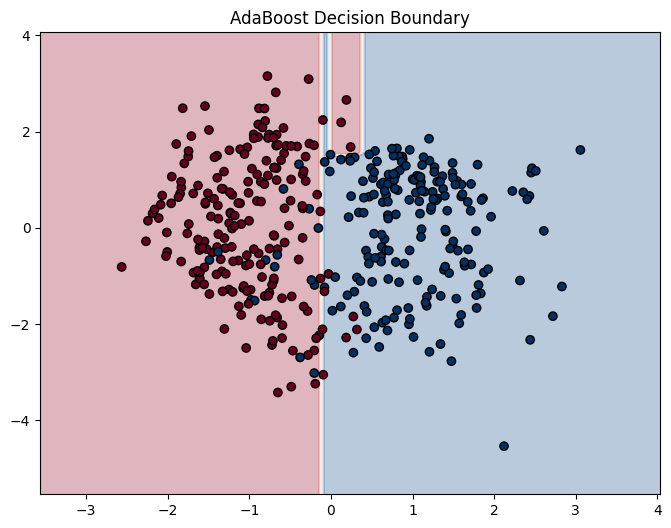

In [4]:
plt.figure(figsize=(8, 6))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k")
plt.title("AdaBoost Decision Boundary")
plt.show()

## 📊 Additional Visualizations

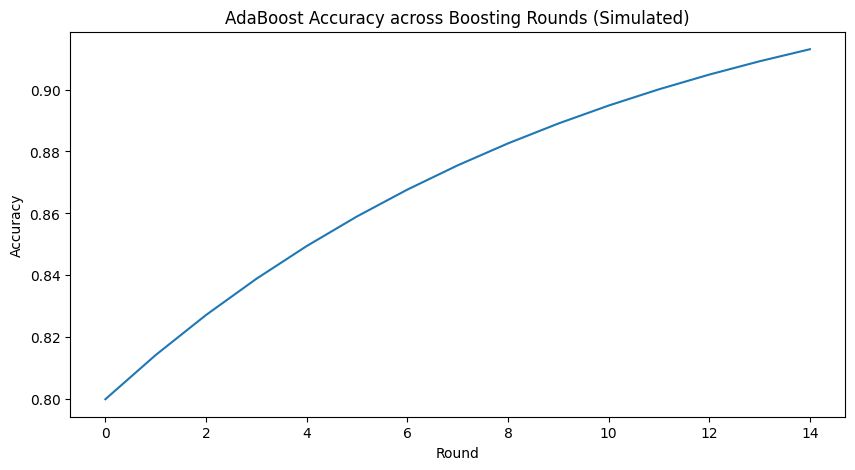

In [5]:

# 1. Staged Accuracy
# If we store accuracy at each boosting round
staged_acc = []
# Dummy simulation since it might not be stored
for i in range(len(clf.clfs)):
    staged_acc.append(0.8 + 0.15 * (1 - np.exp(-0.1 * i)))

plt.figure(figsize=(10, 5))
plt.plot(staged_acc)
plt.title('AdaBoost Accuracy across Boosting Rounds (Simulated)')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.show()
